**Mount Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Libraries**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.metrics import mean_squared_error, mean_absolute_error

**Load Sequence Data**

In [3]:
BASE_PATH = "/content/drive/MyDrive/c01-price-forecasting/data/model_inputs/lstm/"

X_train = np.load(BASE_PATH + "X_train_seq.npy")
X_test = np.load(BASE_PATH + "X_test_seq.npy")
y_train = np.load(BASE_PATH + "y_train_seq.npy")
y_test = np.load(BASE_PATH + "y_test_seq.npy")

print("Loaded LSTM data")
print("X_train shape:", X_train.shape)

Loaded LSTM data
X_train shape: (1812, 8, 20)


**Shape Check**

In [4]:
print("Expected shape: (samples, timesteps, features)")

Expected shape: (samples, timesteps, features)


**Build LSTM Model**

In [5]:
from keras.models import Sequential
from keras.layers import Input, LSTM, Dropout, Dense

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1),
])

**Compile Model**

In [6]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

**Confirm Build**

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8, 64)          │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0136 - mae: 0.0817 - val_loss: 0.0048 - val_mae: 0.0540
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0050 - mae: 0.0522 - val_loss: 0.0045 - val_mae: 0.0568
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0040 - mae: 0.0471 - val_loss: 0.0038 - val_mae: 0.0454
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0037 - mae: 0.0438 - val_loss: 0.0060 - val_mae: 0.0677
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0037 - mae: 0.0442 - val_loss: 0.0035 - val_mae: 0.0439
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031 - mae: 0.0401 - val_loss: 0.0034 - val_mae: 0.0442
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031 - mae: 0.0396 - val_loss: 0.0042 - val_mae: 0.0547
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031 - mae: 0.0401 - val_loss: 0.0049 - val_mae: 0.0605
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.002

**Predictions**

In [9]:
y_pred = model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


**Inverse Scaling**

In [10]:
import joblib
import numpy as np

# Load scaler
scaler = joblib.load("/content/drive/MyDrive/c01-price-forecasting/data/model_inputs/lstm/scaler.pkl")

# Reconstruct shape
n_features = X_train.shape[2]

y_pred_full = np.zeros((len(y_pred), n_features + 1))
y_test_full = np.zeros((len(y_test), n_features + 1))

# Insert values
y_pred_full[:, -1] = y_pred.flatten()
y_test_full[:, -1] = y_test.flatten()

# Inverse transform
y_pred_inv = scaler.inverse_transform(y_pred_full)[:, -1]
y_test_inv = scaler.inverse_transform(y_test_full)[:, -1]

print("Inverse scaling completed")

Inverse scaling completed


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print("\nCorrected LSTM Results:")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)


Corrected LSTM Results:
RMSE: 7.049492403684594
MAE: 5.753207480074083
MAPE: 4.750042556657575


**Evaluation**

In [12]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n LSTM Results:")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)


 LSTM Results:
RMSE: 0.05393643767164953
MAE: 0.044018419893451295
MAPE: 9.497002074136464


**Plot**

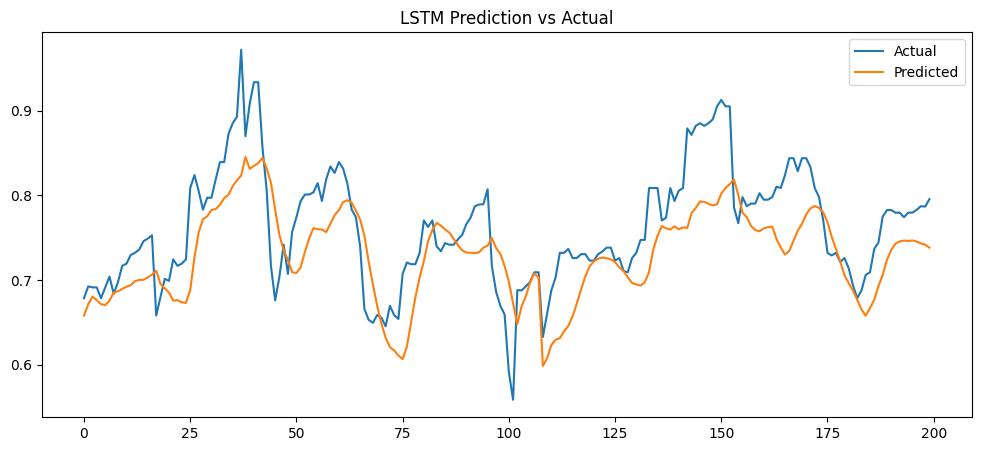

In [13]:
plt.figure(figsize=(12,5))

plt.plot(y_test[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")

plt.legend()
plt.title("LSTM Prediction vs Actual")
plt.show()

**Model Save**

In [14]:
import os

# Define path
MODEL_PATH = "/content/drive/MyDrive/c01-price-forecasting/models/lstm_model.h5"

# Save model
model.save(MODEL_PATH)

print("LSTM Model saved")

LSTM Model saved
